In [1]:
!pip install pyspark pandas matplotlib


In [ ]:
BOOTSTRAP_SERVERS = ""
API_KEY = ""
API_SECRET = ""
TOPIC = "incidents_stream"


In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("IncidentsStreamingConsumer")
    .master("local[*]")
    .config(
        "spark.jars.packages",
        ",".join([
            "org.apache.spark:spark-sql-kafka-0-10_2.13:3.5.1",
            "org.apache.spark:spark-token-provider-kafka-0-10_2.13:3.5.1",
        ])
    )
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")


In [4]:
from pyspark.sql.functions import col, from_json, expr
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

incident_schema = StructType([
    StructField("id",           StringType(), True),
    StructField("reported_at",  StringType(), True),
    StructField("lat",          DoubleType(), True),
    StructField("lon",          DoubleType(), True),
    StructField("alert_code",   StringType(), True),
    StructField("description",  StringType(), True),
    StructField("tag",          StringType(), True),
])

jaas_template = (
    'org.apache.kafka.common.security.plain.PlainLoginModule required '
    'username="{username}" password="{password}";'
)
jaas_cfg = jaas_template.format(username=API_KEY, password=API_SECRET)

kafka_options = {
    "kafka.bootstrap.servers": BOOTSTRAP_SERVERS,
    "kafka.security.protocol": "SASL_SSL",
    "kafka.sasl.mechanism": "PLAIN",
    "kafka.sasl.jaas.config": jaas_cfg,
    "kafka.ssl.endpoint.identification.algorithm": "https",
    "subscribe": TOPIC,
    "startingOffsets": "latest",
}

try:
    raw_stream = (
        spark.readStream
        .format("kafka")
        .options(**kafka_options)
        .load()
    )
except Exception as e:
    print("Error:", e)
    import traceback; traceback.print_exc()


json_stream = raw_stream.selectExpr("CAST(value AS STRING) as json_str")

parsed_stream = (
    json_stream
    .select(from_json(col("json_str"), incident_schema).alias("data"))
    .select("data.*")
)

incidents_stream = parsed_stream.withColumn(
    "reported_at_ts",
    expr("to_timestamp(reported_at)")
)

incidents_stream.printSchema()


root
 |-- id: string (nullable = true)
 |-- reported_at: string (nullable = true)
 |-- lat: double (nullable = true)
 |-- lon: double (nullable = true)
 |-- alert_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- tag: string (nullable = true)
 |-- reported_at_ts: timestamp (nullable = true)



In [5]:
from pyspark.sql.functions import window
from pyspark.sql.functions import window, col, round as spark_round

agg_by_type = (
    incidents_stream
    .groupBy(
        window(col("reported_at_ts"), "1 minute"),
        col("alert_code")
    )
    .count()
)

query = (
    agg_by_type
    .writeStream
    .outputMode("complete")
    .format("memory")          # tabel in-memory
    .queryName("incidents_by_type")
    .start()
)


agg_hotspots = (
    incidents_stream
    .withColumn("lat2", spark_round(col("lat"), 2))
    .withColumn("lon2", spark_round(col("lon"), 2))
    .groupBy(
        window(col("reported_at_ts"), "1 minute"),
        col("lat2"),
        col("lon2")
    )
    .count()
)

q_hotspots = (
    agg_hotspots.writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("incidents_hotspots")
    .start()
)

print("Hotspots query started.")
print("Streaming query started.")


Hotspots query started.
Streaming query started. Lasă producer-ul să trimită mesaje câteva secunde...


In [15]:
agg_by_tag = (
    incidents_stream
    .groupBy(
        window(col("reported_at_ts"), "1 minute"),
        col("tag")
    )
    .count()
)

q_tags = (
    agg_by_tag
    .writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("incidents_by_tag")
    .start()
)

In [18]:
agg_code_tag = (
    incidents_stream
    .groupBy(
        window(col("reported_at_ts"), "1 minute"),
        col("alert_code"),
        col("tag")
    )
    .count()
)

q_code_tag = (
    agg_code_tag
    .writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("incidents_code_tag")
    .start()
)


In [22]:
raw_points = incidents_stream.select(
    col("reported_at_ts"),
    col("lat").alias("lat"),
    col("lon").alias("lon")
)

q_points = (
    raw_points.writeStream
    .outputMode("append")
    .format("memory")
    .queryName("incidents_points")
    .start()
)


In [8]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_dashboard(refresh_sec=2, last_minutes=5):
    while True:
        pdf = spark.sql("""
            SELECT
                window.start AS window_start,
                window.end   AS window_end,
                alert_code,
                count
            FROM incidents_by_type
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        totals_all = (
            pdf.groupby("alert_code")["count"]
            .sum()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(7,4))
        plt.bar(totals_all.index, totals_all.values)
        plt.title("Total incidente pe tip (de la pornire)")
        plt.xlabel("Alert code")
        plt.ylabel("Număr incidente")
        plt.tight_layout()
        plt.show()

        latest_end = pdf["window_end"].max()
        cutoff = latest_end - timedelta(minutes=last_minutes)
        recent = pdf[pdf["window_end"] >= cutoff]

        totals_recent = (
            recent.groupby("alert_code")["count"]
            .sum()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(7,4))
        plt.bar(totals_recent.index, totals_recent.values)
        plt.title(f"Incidente pe tip (ultimele {last_minutes} minute)")
        plt.xlabel("Alert code")
        plt.ylabel("Număr incidente")
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)

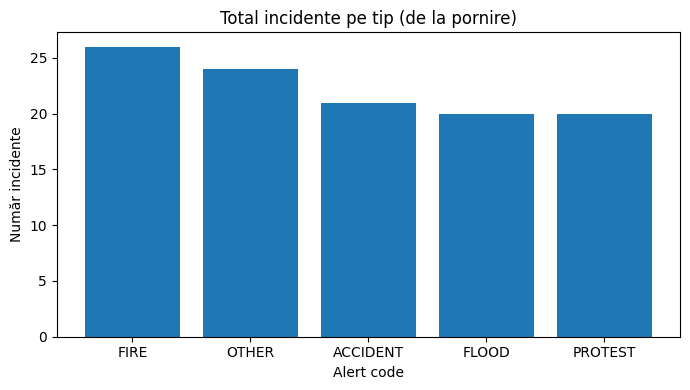

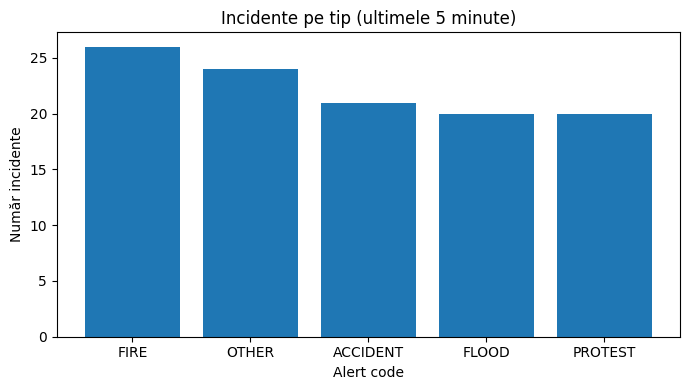

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [9]:
live_dashboard(refresh_sec=2, last_minutes=5)


In [10]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_hotspots_heatmap(refresh_sec=2, last_minutes=5):
    while True:
        pdf = spark.sql("""
            SELECT window.end AS window_end, lat2, lon2, count
            FROM incidents_hotspots
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_end = pdf["window_end"].max()
        cutoff = latest_end - timedelta(minutes=last_minutes)
        recent = pdf[pdf["window_end"] >= cutoff]

        if recent.empty:
            print(f"No data in last {last_minutes} minutes.")
            time.sleep(refresh_sec)
            continue

        pivot = recent.pivot_table(
            index="lat2", columns="lon2", values="count",
            aggfunc="sum", fill_value=0
        ).sort_index()

        plt.figure(figsize=(9,6))
        plt.imshow(pivot.values, aspect="auto", origin="lower")
        plt.title(f"Hotspots heatmap (ultimele {last_minutes} minute)")
        plt.xlabel("lon2")
        plt.ylabel("lat2")

        plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45, ha="right")
        plt.yticks(range(len(pivot.index)), [str(y) for y in pivot.index])

        plt.colorbar(label="count")
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)



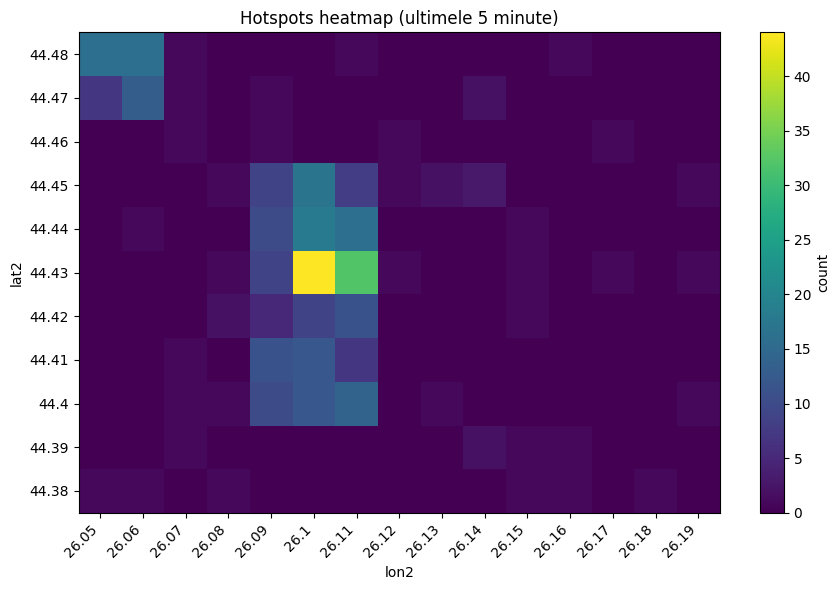

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

In [27]:
live_hotspots_heatmap(refresh_sec=2, last_minutes=5)


In [32]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_geospatial_scatter(refresh_sec=2, last_minutes=5, max_points=1500):
    while True:
        pdf = spark.sql("""
            SELECT reported_at_ts AS ts, lat, lon
            FROM incidents_points
            WHERE reported_at_ts IS NOT NULL
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_t = pdf["ts"].max()
        cutoff = latest_t - timedelta(minutes=last_minutes)
        recent = pdf[pdf["ts"] >= cutoff].copy()

        if recent.empty:
            print(f"No data in last {last_minutes} minutes.")
            time.sleep(refresh_sec)
            continue

        if len(recent) > max_points:
            recent = recent.tail(max_points)

        plt.figure(figsize=(6,6))
        plt.scatter(recent["lon"], recent["lat"], s=8, alpha=0.8)
        plt.title(f"Geospatial Distribution (ultimele {last_minutes} minute)")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.xlim(26.03, 26.22)
        plt.ylim(44.37, 44.49)
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)



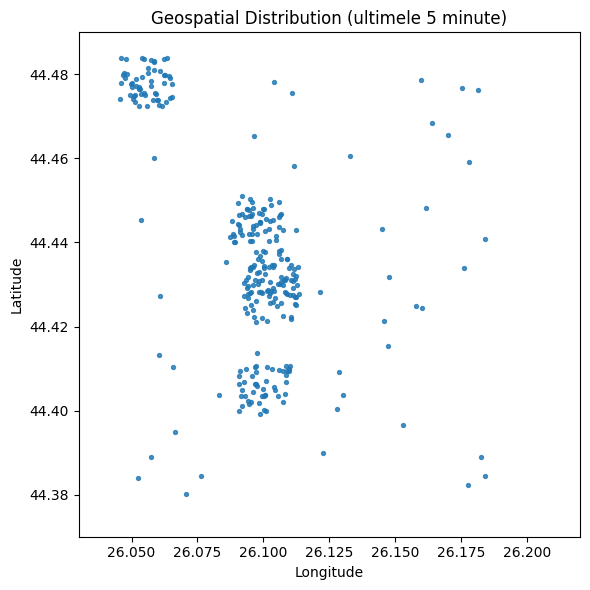

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [33]:
live_geospatial_scatter(refresh_sec=2, last_minutes=5)


In [12]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_hotspots_scatter(refresh_sec=2, last_minutes=5):
    while True:
        pdf = spark.sql("""
            SELECT window.end AS window_end, lat2, lon2, count
            FROM incidents_hotspots
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_end = pdf["window_end"].max()
        cutoff = latest_end - timedelta(minutes=last_minutes)
        recent = pdf[pdf["window_end"] >= cutoff]

        if recent.empty:
            print(f"No data in last {last_minutes} minutes.")
            time.sleep(refresh_sec)
            continue

        agg = (recent.groupby(["lat2","lon2"])["count"]
               .sum()
               .reset_index())

        plt.figure(figsize=(8,6))
        plt.scatter(agg["lon2"], agg["lat2"], s=agg["count"]*40, alpha=0.7)
        plt.title(f"Hotspots scatter (ultimele {last_minutes} minute)")
        plt.xlabel("lon2")
        plt.ylabel("lat2")
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)



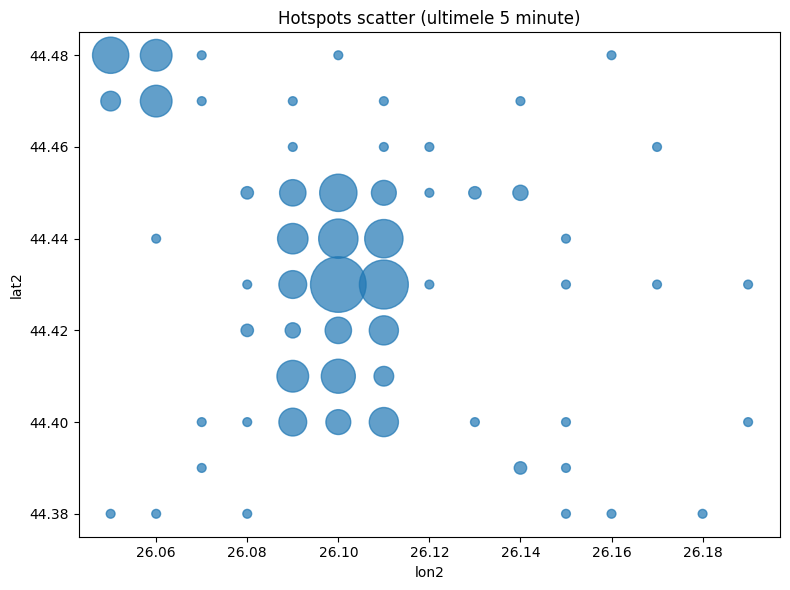

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [28]:
live_hotspots_scatter(refresh_sec=2, last_minutes=5)


In [34]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_tags_dashboard(refresh_sec=2, last_minutes=5):
    while True:
        pdf = spark.sql("""
            SELECT
                window.end AS window_end,
                tag,
                count
            FROM incidents_by_tag
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_end = pdf["window_end"].max()
        cutoff = latest_end - timedelta(minutes=last_minutes)
        recent = pdf[pdf["window_end"] >= cutoff]

        totals = (
            recent.groupby("tag")["count"]
            .sum()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(6,4))
        plt.bar(totals.index, totals.values)
        plt.title(f"Severitate incidente (ultimele {last_minutes} minute)")
        plt.xlabel("tag (severity)")
        plt.ylabel("număr incidente")
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)


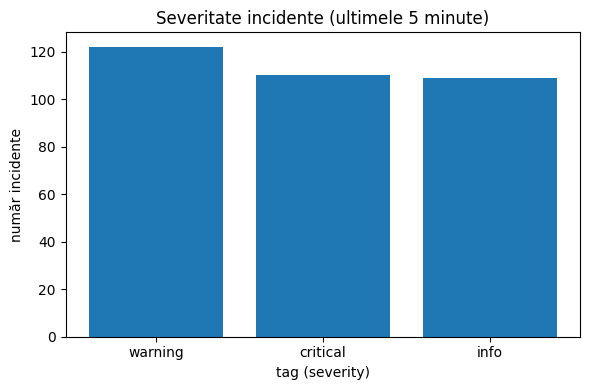

KeyboardInterrupt: 

In [35]:
live_tags_dashboard(refresh_sec=2, last_minutes=5)


In [19]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta

def live_code_tag_heatmap(refresh_sec=2, last_minutes=5):
    while True:
        pdf = spark.sql("""
            SELECT
                window.end AS window_end,
                alert_code,
                tag,
                count
            FROM incidents_code_tag
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_end = pdf["window_end"].max()
        cutoff = latest_end - timedelta(minutes=last_minutes)
        recent = pdf[pdf["window_end"] >= cutoff]

        if recent.empty:
            print(f"No data in last {last_minutes} minutes.")
            time.sleep(refresh_sec)
            continue

        agg = (
            recent.groupby(["alert_code", "tag"])["count"]
            .sum()
            .reset_index()
        )

        pivot = agg.pivot_table(
            index="alert_code",
            columns="tag",
            values="count",
            aggfunc="sum",
            fill_value=0
        )

        preferred = ["critical", "warning", "info"]
        cols = [c for c in preferred if c in pivot.columns] + [c for c in pivot.columns if c not in preferred]
        pivot = pivot[cols]

        plt.figure(figsize=(7,4))
        plt.imshow(pivot.values, aspect="auto", origin="lower")
        plt.title(f"Heatmap: alert_code × tag (ultimele {last_minutes} minute)")
        plt.xlabel("tag")
        plt.ylabel("alert_code")

        plt.xticks(range(len(pivot.columns)), pivot.columns)
        plt.yticks(range(len(pivot.index)), pivot.index)

        plt.colorbar(label="count")
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)



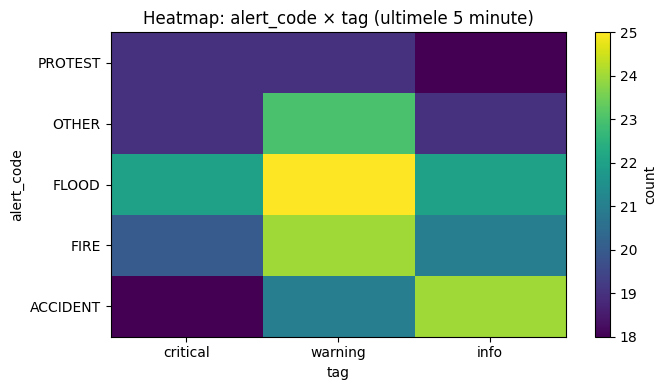

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [25]:
live_code_tag_heatmap(refresh_sec=2, last_minutes=5)


In [23]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from datetime import timedelta
import numpy as np
from sklearn.cluster import KMeans

def live_kmeans(refresh_sec=5, last_minutes=5, k=5, max_points=1000):
    while True:
        pdf = spark.sql("""
            SELECT reported_at_ts, lat, lon
            FROM incidents_points
            WHERE reported_at_ts IS NOT NULL
        """).toPandas()

        clear_output(wait=True)

        if pdf.empty:
            print("Waiting for data.")
            time.sleep(refresh_sec)
            continue

        latest_t = pdf["reported_at_ts"].max()
        cutoff = latest_t - timedelta(minutes=last_minutes)
        recent = pdf[pdf["reported_at_ts"] >= cutoff].copy()

        if recent.empty:
            print(f"No data in last {last_minutes} minutes.")
            time.sleep(refresh_sec)
            continue

        if len(recent) > max_points:
            recent = recent.tail(max_points)

        X = recent[["lon", "lat"]].to_numpy()

        kk = min(k, len(recent))
        if kk < 2:
            print("Not enough points for clustering yet.")
            time.sleep(refresh_sec)
            continue

        km = KMeans(n_clusters=kk, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        centers = km.cluster_centers_

        plt.figure(figsize=(8,6))
        plt.scatter(X[:,0], X[:,1], c=labels, s=25, alpha=0.75)
        plt.scatter(centers[:,0], centers[:,1], marker="X", s=250)
        plt.title(f"KMeans clustering (k={kk}) – ultimele {last_minutes} minute")
        plt.xlabel("Longitude (lon)")
        plt.ylabel("Latitude (lat)")
        plt.xlim(26.03, 26.22)
        plt.ylim(44.37, 44.49)
        plt.tight_layout()
        plt.show()

        time.sleep(refresh_sec)



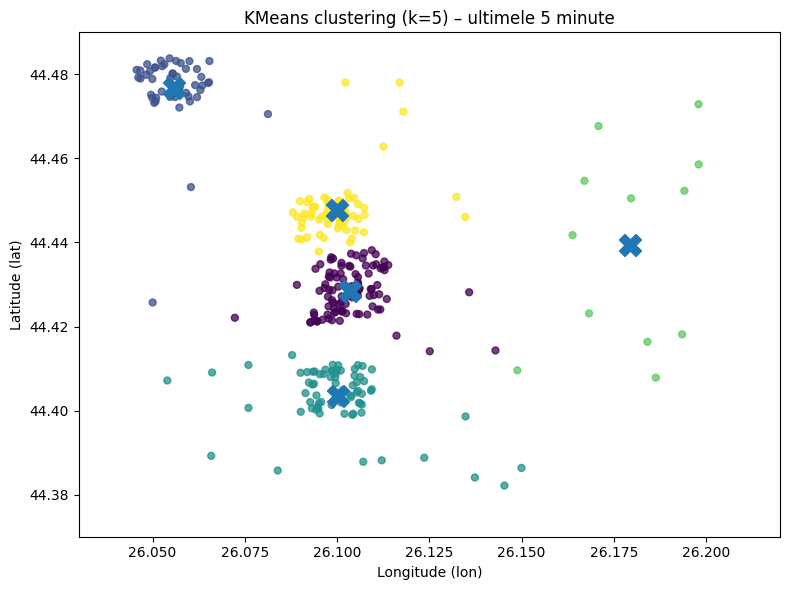

KeyboardInterrupt: 

In [30]:
live_kmeans(refresh_sec=5, last_minutes=5, k=5)
